exam_score                1.000000
previous_gpa              0.932940
motivation_level          0.250287
study_hours_per_day       0.241460
screen_time               0.169788
sleep_hours               0.090820
exercise_frequency        0.086983
mental_health_rating      0.010556
student_id                0.007557
time_management_score     0.005940
attendance_percentage     0.002876
semester                  0.000541
age                       0.000487
netflix_hours            -0.001271
social_activity          -0.002795
parental_support_level   -0.006333
social_media_hours       -0.006351
stress_level             -0.118550
exam_anxiety_score       -0.235909
Name: exam_score, dtype: float64


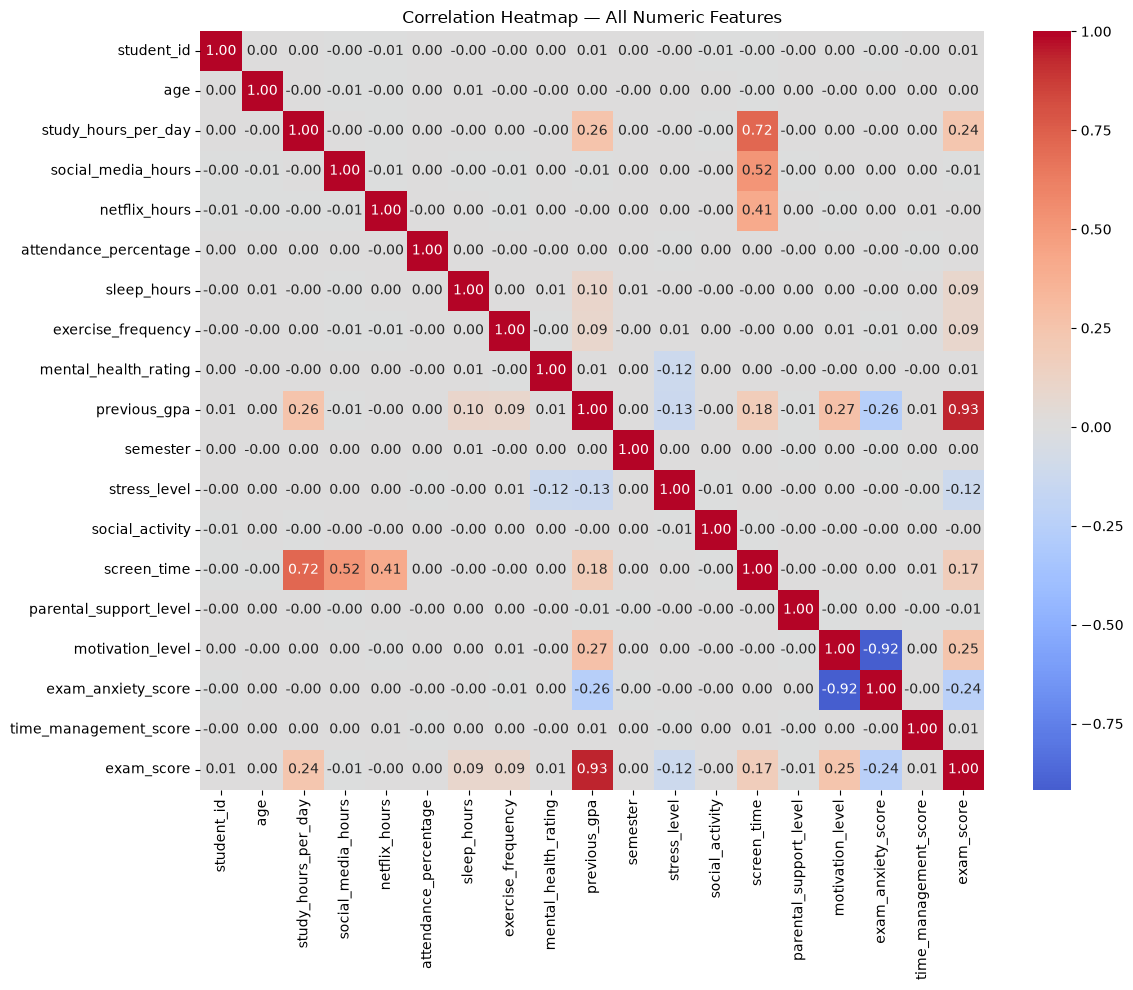

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/studytrack_cleaned.csv')
df.shape

numeric_df = df.select_dtypes(include=[np.number])
corr_with_score = numeric_df.corr()['exam_score'].sort_values(ascending=False)
print(corr_with_score)

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
cat_cols = ['gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level',
               'internet_quality', 'extracurricular_participation', 'dropout_risk',
               'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']

for col in cat_cols:
       print(f"\n--- {col} ---")
       print(df.groupby(col)['exam_score'].mean().sort_values(ascending=False))


--- gender ---
gender
Other     89.163665
Male      89.152034
Female    89.108444
Name: exam_score, dtype: float64

--- major ---
major
Computer Science    90.271794
Engineering         89.099478
Business            88.959476
Biology             88.850163
Psychology          88.842003
Arts                88.825990
Name: exam_score, dtype: float64

--- part_time_job ---
part_time_job
No     89.167085
Yes    89.115362
Name: exam_score, dtype: float64

--- diet_quality ---
diet_quality
Fair    89.272676
Poor    89.171959
Good    89.043270
Name: exam_score, dtype: float64

--- parental_education_level ---
parental_education_level
PhD             89.189928
Master          89.173875
High School     89.140072
Bachelor        89.129488
Some College    89.074403
Name: exam_score, dtype: float64

--- internet_quality ---
internet_quality
Low       89.185558
High      89.125051
Medium    89.113276
Name: exam_score, dtype: float64

--- extracurricular_participation ---
extracurricular_participati

In [8]:
# Bucket previous_gpa into bands so we compare like-with-like
df['gpa_band'] = pd.cut(df['previous_gpa'], bins=[0, 2.5, 3.0, 3.5, 4.0], 
                          labels=['Low (0-2.5)', 'Medium (2.5-3.0)', 'High (3.0-3.5)', 'Very High (3.5-4.0)'])

# Within each GPA band, check correlation of habits with exam_score
habit_cols = ['study_hours_per_day', 'motivation_level', 'exam_anxiety_score', 
              'stress_level', 'sleep_hours', 'screen_time', 'exercise_frequency']

for band in df['gpa_band'].cat.categories:
    subset = df[df['gpa_band'] == band]
    print(f"\n=== GPA Band: {band} (n={len(subset)}) ===")
    print(subset[habit_cols + ['exam_score']].corr()['exam_score'].sort_values(ascending=False))


=== GPA Band: Low (0-2.5) (n=1725) ===
exam_score             1.000000
study_hours_per_day    0.124638
screen_time            0.085278
motivation_level       0.076791
exercise_frequency     0.068933
sleep_hours            0.034505
exam_anxiety_score    -0.057095
stress_level          -0.131030
Name: exam_score, dtype: float64

=== GPA Band: Medium (2.5-3.0) (n=9405) ===
exam_score             1.000000
study_hours_per_day    0.092665
screen_time            0.075803
motivation_level       0.059485
sleep_hours            0.039015
exercise_frequency     0.011328
stress_level          -0.025243
exam_anxiety_score    -0.053429
Name: exam_score, dtype: float64

=== GPA Band: High (3.0-3.5) (n=17462) ===
exam_score             1.000000
motivation_level       0.042782
study_hours_per_day    0.032765
screen_time            0.025248
exercise_frequency     0.023384
sleep_hours            0.023091
stress_level          -0.013712
exam_anxiety_score    -0.047665
Name: exam_score, dtype: float64

===

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['study_hours_per_day', 'social_media_hours', 'netflix_hours', 
                     'sleep_hours', 'screen_time', 'exercise_frequency', 
                     'motivation_level', 'stress_level', 'exam_anxiety_score',
                     'time_management_score']

X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(80000, 10)

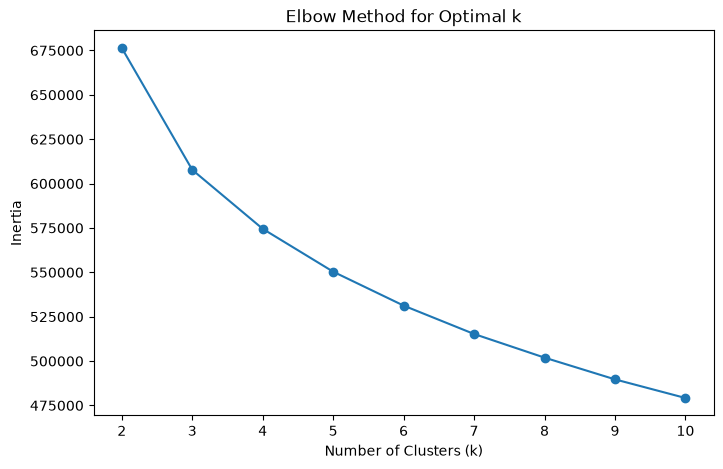

In [10]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.savefig('../notebooks/elbow_method.png', dpi=150)
plt.show()

In [11]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

df['cluster'].value_counts().sort_index()

cluster
0    15219
1    17820
2    16705
3    15084
4    15172
Name: count, dtype: int64

In [14]:
profile_cols = cluster_features + ['exam_score', 'previous_gpa']
cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile

,study_hours_per_day,social_media_hours,netflix_hours,sleep_hours,screen_time,exercise_frequency,motivation_level,stress_level,exam_anxiety_score,time_management_score,exam_score,previous_gpa
cluster,,,,,,,,,,,,
0,3.10,1.70,1.66,7.01,7.41,3.58,8.56,5.00,6.44,5.49,91.19,3.69
1,3.36,1.17,1.77,7.02,7.25,3.54,3.45,4.98,9.84,5.42,85.89,3.46
2,5.92,2.90,2.63,7.02,12.51,3.54,3.49,4.95,9.82,5.50,89.86,3.63
3,3.10,3.78,1.53,7.01,9.40,3.41,3.92,5.11,9.65,5.58,85.57,3.45
4,5.34,3.17,2.37,7.02,11.93,3.50,8.56,5.02,6.44,5.52,93.66,3.80


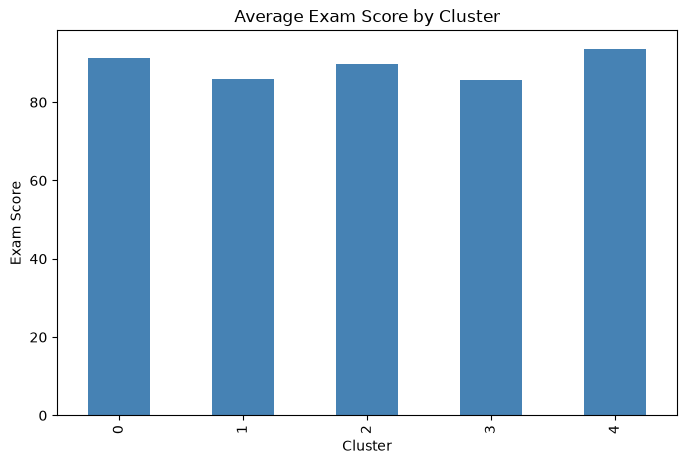

In [13]:
plt.figure(figsize=(8, 5))
df.groupby('cluster')['exam_score'].mean().plot(kind='bar', color='steelblue')
plt.title('Average Exam Score by Cluster')
plt.ylabel('Exam Score')
plt.xlabel('Cluster')
plt.savefig('../notebooks/cluster_exam_scores.png', dpi=150)
plt.show()

In [15]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(kmeans_final, '../models/student_cluster_model.pkl')
joblib.dump(scaler, '../models/cluster_scaler.pkl')

print("Cluster model and scaler saved.")

Cluster model and scaler saved.


In [16]:
cluster_names = {
    0: "Efficient Achiever",
    1: "Anxious & Disengaged",
    2: "Anxious Grinder",
    3: "Distracted Underachiever",
    4: "Peak Performer"
}

import json
with open('../models/cluster_names.json', 'w') as f:
    json.dump(cluster_names, f, indent=2)

df['cluster_name'] = df['cluster'].map(cluster_names)
df.to_csv('../data/studytrack_clustered.csv', index=False)
print("Clustered dataset saved:", df.shape)

Clustered dataset saved: (80000, 34)
